# Exploratory Data Analysis (EDA)

Project:
MarketMind AI

Module:
Forecasting & Time Series Analysis

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [19]:
df = pd.read_csv("data/marketmind_sales_dataset.csv")

In [20]:
print("First 5 Records")
display(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()

First 5 Records


,transaction_id,invoice_id,transaction_date,customer_id,product_id,product_name,category,quantity,unit_price,discount,total_amount,payment_method,store_id
0,TXN0001,INV0001,2026-05-12,C020,P011,Eggs 12pc,Dairy,6.0,90,10.0,530.0,Card,S001
1,TXN0002,INV0002,2026-06-14,C031,P009,Notebook,Stationery,5.0,50,5.0,245.0,Cash,S003
2,TXN0003,INV0003,2026-03-30,C014,P004,Sugar 1kg,Grocery,1.0,55,0.0,55.0,Card,S001
3,TXN0004,INV0004,2026-02-25,C015,P009,Notebook,Stationery,3.0,50,15.0,135.0,Cash,S003
4,TXN0005,INV0005,2026-03-04,NaN,P005,Tea Powder,Beverages,7.0,180,5.0,1255.0,Card,S003



Dataset Shape
(200, 13)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    199 non-null    str    
 1   invoice_id        199 non-null    str    
 2   transaction_date  200 non-null    str    
 3   customer_id       198 non-null    str    
 4   product_id        199 non-null    str    
 5   product_name      199 non-null    str    
 6   category          199 non-null    str    
 7   quantity          199 non-null    float64
 8   unit_price        199 non-null    str    
 9   discount          199 non-null    float64
 10  total_amount      199 non-null    float64
 11  payment_method    199 non-null    str    
 12  store_id          199 non-null    str    
dtypes: float64(3), str(10)
memory usage: 32.5 KB


In [21]:
# Convert transaction_date to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

# Convert unit_price to numeric
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

# Check missing values
print("\nMissing Values Before Cleaning")
print(df.isnull().sum())

# Fill numeric missing values with median
numeric_cols = ["quantity", "unit_price", "discount", "total_amount"]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
categorical_cols = [
    "transaction_id",
    "invoice_id",
    "customer_id",
    "product_id",
    "product_name",
    "category",
    "payment_method",
    "store_id"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicate rows
df = df.drop_duplicates()

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())


Missing Values Before Cleaning
transaction_id      1
invoice_id          1
transaction_date    3
customer_id         2
product_id          1
product_name        1
category            1
quantity            1
unit_price          2
discount            1
total_amount        1
payment_method      1
store_id            1
dtype: int64

Missing Values After Cleaning
transaction_id      0
invoice_id          0
transaction_date    3
customer_id         0
product_id          0
product_name        0
category            0
quantity            0
unit_price          0
discount            0
total_amount        0
payment_method      0
store_id            0
dtype: int64

Duplicate Records
0


In [22]:
df.describe(include='all')

,transaction_id,invoice_id,transaction_date,customer_id,product_id,product_name,category,quantity,unit_price,discount,total_amount,payment_method,store_id
count,199,199,196,199,199,199,199,199.000000,199.000000,199.000000,199.000000,199,199
unique,197,197,NaN,42,21,22,10,NaN,NaN,NaN,NaN,6,5
top,TXN0001,INV0003,NaN,C015,P002,Bread Loaf,Grocery,NaN,NaN,NaN,NaN,Card,S002
freq,3,2,NaN,11,17,17,34,NaN,NaN,NaN,NaN,50,73
mean,NaN,NaN,2026-03-30 08:12:14.693877,NaN,NaN,NaN,NaN,9.402010,131.170854,9.748744,1054.639899,NaN,NaN
min,NaN,NaN,2026-01-04 00:00:00,NaN,NaN,NaN,NaN,-2.000000,-40.000000,-5.000000,0.000000,NaN,NaN
25%,NaN,NaN,2026-02-11 00:00:00,NaN,NaN,NaN,NaN,2.000000,60.000000,0.000000,194.000000,NaN,NaN
50%,NaN,NaN,2026-04-02 00:00:00,NaN,NaN,NaN,NaN,5.000000,110.000000,5.000000,415.000000,NaN,NaN
75%,NaN,NaN,2026-05-13 06:00:00,NaN,NaN,NaN,NaN,6.000000,180.000000,15.000000,815.000000,NaN,NaN
max,NaN,NaN,2026-06-29 00:00:00,NaN,NaN,NaN,NaN,1000.000000,420.000000,500.000000,99999.000000,NaN,NaN


In [29]:
#filling missing transaction_dates with their medians
df['transaction_date'] = df['transaction_date'].fillna(df['transaction_date'].median())
df['transaction_date'].isnull().sum()

np.int64(0)

In [30]:
df['transaction_date'].dtype

dtype('<M8[us]')

## EDA visualization

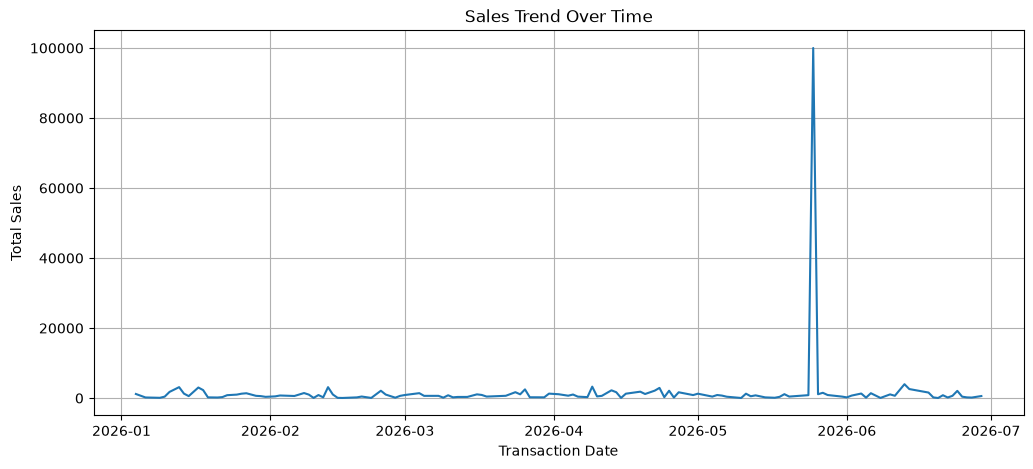

In [31]:
#sales trend over time
daily_sales = df.groupby("transaction_date")["total_amount"].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Sales Trend Over Time")
plt.xlabel("Transaction Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

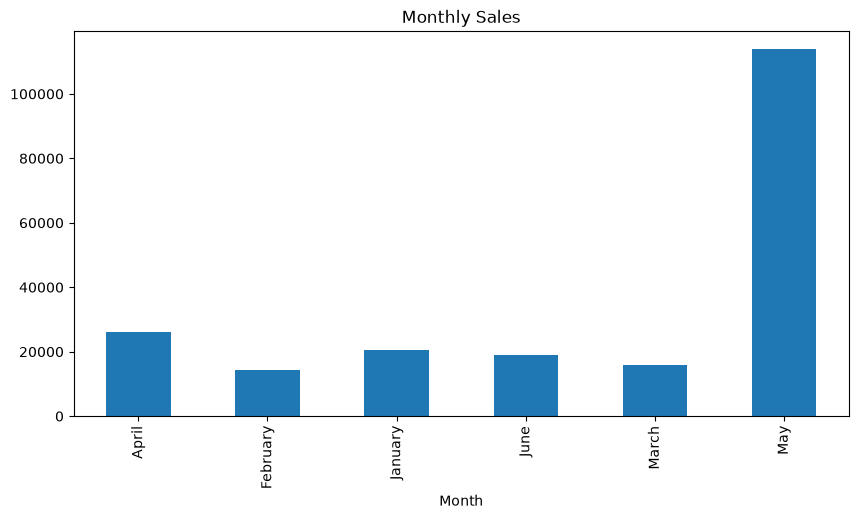

In [32]:
#monthly seasonality
df["Month"] = df["transaction_date"].dt.month_name()

monthly_sales = df.groupby("Month")["total_amount"].sum()

monthly_sales.plot(kind="bar", figsize=(10,5))
plt.title("Monthly Sales")
plt.show()

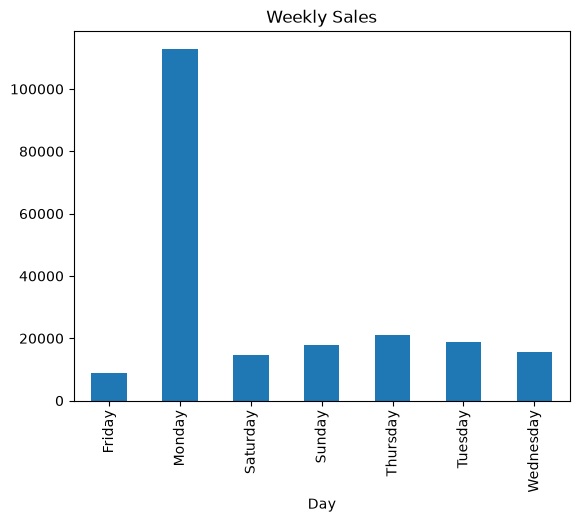

In [33]:
#weekly seasonalities
df["Day"] = df["transaction_date"].dt.day_name()

weekly_sales = df.groupby("Day")["total_amount"].sum()

weekly_sales.plot(kind="bar")
plt.title("Weekly Sales")
plt.show()

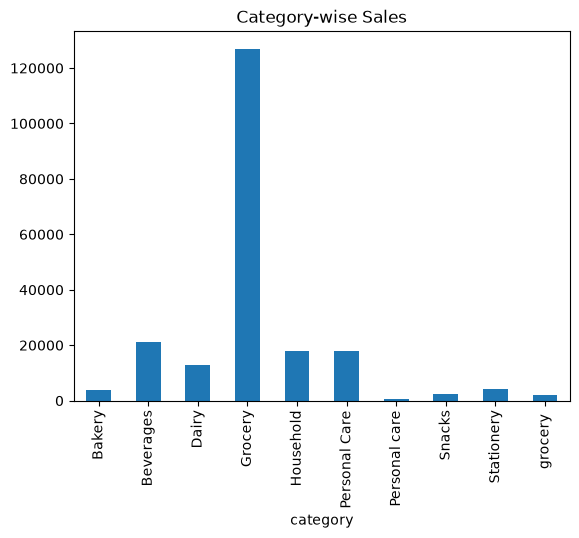

In [34]:
#category-wise sales
category_sales = df.groupby("category")["total_amount"].sum()

category_sales.plot(kind="bar")
plt.title("Category-wise Sales")
plt.show()

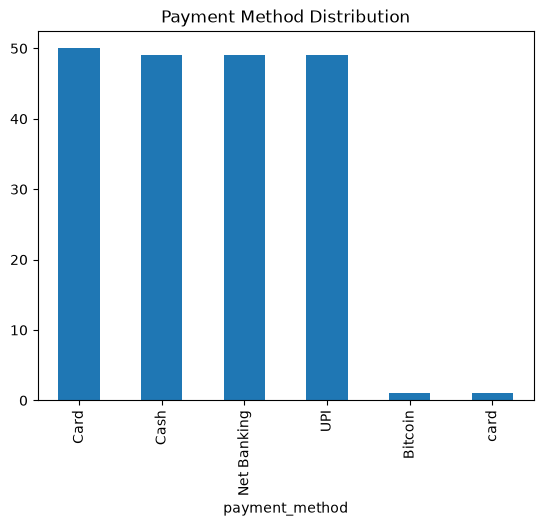

In [35]:
#payment method analysis
df["payment_method"].value_counts().plot(kind="bar")
plt.title("Payment Method Distribution")
plt.show()

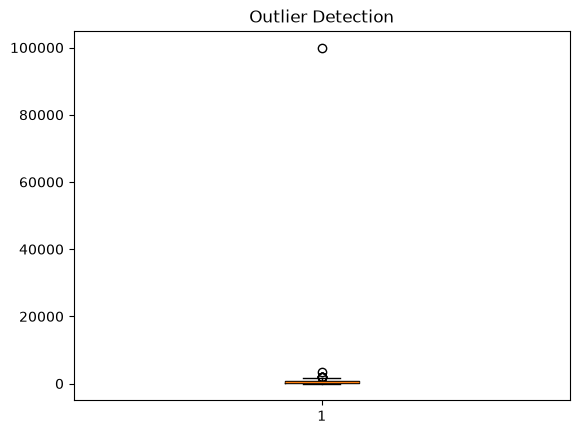

In [36]:
#outlier detection
plt.boxplot(df["total_amount"])
plt.title("Outlier Detection")
plt.show()

              quantity  unit_price  discount  total_amount
quantity      1.000000   -0.065196 -0.015544     -0.011345
unit_price   -0.065196    1.000000 -0.032296      0.138770
discount     -0.015544   -0.032296  1.000000      0.011137
total_amount -0.011345    0.138770  0.011137      1.000000


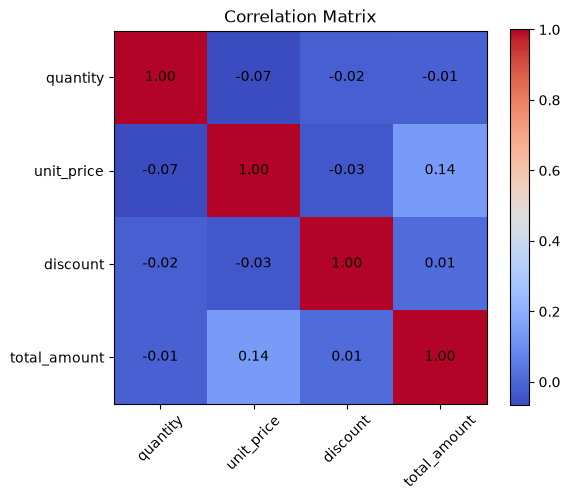

In [38]:
#correlation analysis
print(df[["quantity","unit_price","discount","total_amount"]].corr())
import matplotlib.pyplot as plt

# Select numeric columns
corr = df[["quantity", "unit_price", "discount", "total_amount"]].corr()

# Create heatmap
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

# Labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values inside each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()